# Trabajo Aplicado – Series de Tiempo
## Pronóstico del número de graduados del programa de Estadística, sede Bogotá

En este cuaderno se desarrolla el análisis completo de la serie: descripción, gráfico, transformación, estacionariedad, ACF/PACF (con umbrales de significancia), ajuste y comparación de modelos AR, MA, ARIMA, SARIMA y GARCH mediante AIC/BIC, diagnóstico de residuos del modelo GARCH y pronóstico de los próximos 4 periodos (semestres).

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy import stats
from arch import arch_model
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# 1. Carga de datos y descripción de la serie

La serie corresponde al número total de graduados por semestre del programa de Estadística, sede Bogotá, Universidad Nacional de Colombia. La fuente es el Sistema de Información Académica (SIA) / Observatorio de la Universidad Nacional. La variable `period` (Semestre) toma únicamente los valores **1** (enero-junio) y **2** (agosto-diciembre); cada año tiene por lo tanto dos observaciones (1 y 2), por lo que se construye una **etiqueta de periodo `AAAA-S`** (p. ej. `2009-1`, `2009-2`) y se trabaja con un **índice secuencial** para el modelado, evitando así cualquier distorsión por el uso de frecuencias trimestrales (`Q`).

In [2]:
ruta = []
for i in Path('.', 'data').rglob('*.csv'):
    ruta.append(i)

data = pd.read_csv(ruta[0], skiprows=1, names=['year', 'period', 'total'])
data['year'] = data['year'].astype(int)
data['period'] = data['period'].astype(int)   # solo toma valores 1 o 2 (semestre)
data['total'] = data['total'].astype(float)

# Orden cronológico ascendente y construcción de la etiqueta de periodo AAAA-S (S = 1 o 2)
data = data.sort_values(['year', 'period']).reset_index(drop=True)
data['periodo'] = data['year'].astype(str) + '-' + data['period'].astype(str)

# Índice secuencial para el modelado (1 observación = 1 semestre)
data.index = pd.RangeIndex(start=0, stop=len(data), name='t')
serie = data['total']
etiquetas = data['periodo']
data.head()

,year,period,total,periodo
t,,,,
0,2009,1,8.0,2009-1
1,2009,2,13.0,2009-2
2,2010,1,15.0,2010-1
3,2010,2,18.0,2010-2
4,2011,1,27.0,2011-1


In [3]:
print(f'Número de observaciones: {len(serie)}')
print(f'Periodo: {etiquetas.iloc[0]} -- {etiquetas.iloc[-1]}')
serie.describe()

Número de observaciones: 34
Periodo: 2009-1 -- 2025-2


count    34.000000
mean     24.264706
std      10.287706
min       2.000000
25%      18.250000
50%      24.500000
75%      30.500000
max      54.000000
Name: total, dtype: float64

# 2. Gráfico de la serie original e interpretación

Se grafica la serie original (con las etiquetas reales `AAAA-S`) para observar tendencia, cambios de varianza y posibles valores atípicos.

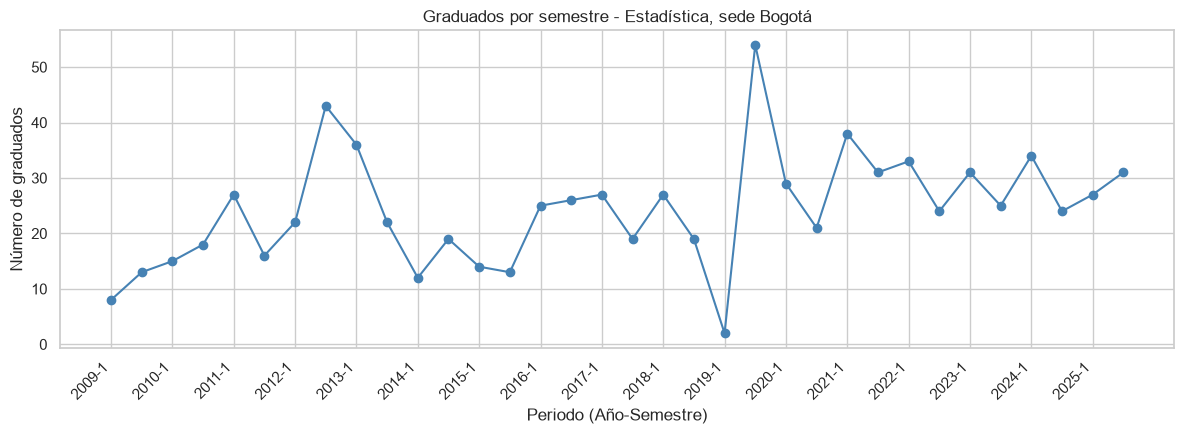

In [4]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(serie.index, serie.values, marker='o', color='steelblue')
paso = 2
ax.set_xticks(serie.index[::paso])
ax.set_xticklabels(etiquetas.values[::paso], rotation=45, ha='right')
ax.set_title('Graduados por semestre - Estadística, sede Bogotá')
ax.set_xlabel('Periodo (Año-Semestre)')
ax.set_ylabel('Número de graduados')
plt.tight_layout()
plt.savefig('serie_original.png', dpi=150)
plt.show()

# 3. Transformación para estabilizar la varianza

Antes de modelar la heterocedasticidad condicional (GARCH), se evalúa si la serie requiere una transformación. Se calcula el lambda óptimo de Box-Cox como referencia y se compara la varianza entre la primera y la segunda mitad de la serie.

Lambda óptimo de Box-Cox: 0.776
Varianza primera mitad: 82.81 | Varianza segunda mitad: 112.01


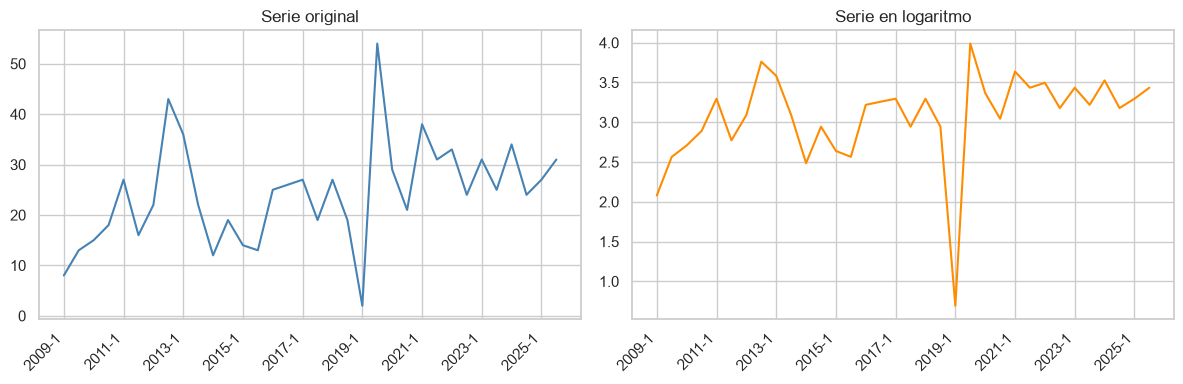

In [5]:
# Lambda óptimo de Box-Cox
bc_vals, bc_lambda = stats.boxcox(serie.values)
print(f'Lambda óptimo de Box-Cox: {bc_lambda:.3f}')

# Comparación de varianza en dos mitades de la serie
mitad = len(serie) // 2
var1, var2 = serie.iloc[:mitad].var(), serie.iloc[mitad:].var()
print(f'Varianza primera mitad: {var1:.2f} | Varianza segunda mitad: {var2:.2f}')

log_serie = np.log(serie)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(serie.index, serie.values, color='steelblue')
axes[0].set_title('Serie original')
axes[1].plot(log_serie.index, log_serie.values, color='darkorange')
axes[1].set_title('Serie en logaritmo')
for ax in axes:
    ax.set_xticks(serie.index[::4])
    ax.set_xticklabels(etiquetas.values[::4], rotation=45, ha='right')
plt.tight_layout()
plt.savefig('serie_transformada.png', dpi=150)
plt.show()

**Justificación:** dado que $\hat\lambda$ de Box-Cox se encuentra cercano a 1 pero la varianza entre la primera y la segunda mitad de la serie difiere, se trabaja con la transformación logarítmica $y_t = \log(\text{total}_t)$. Asi se estabiliza la varianza y permite interpretar los rezagos $r_t = y_t - y_{t-1}$ como tasas de crecimiento, base para la comparación de modelos en las secciones siguientes.

# 4. Análisis de estacionariedad

Se aplican las pruebas de Dickey-Fuller Aumentada (ADF, H0: no estacionaria) y KPSS (H0: estacionaria) sobre la serie transformada, y se evalúa la necesidad de diferenciación.

In [6]:
def reporte_estacionariedad(x, nombre):
    adf = adfuller(x.dropna(), autolag='AIC')
    kp = kpss(x.dropna(), regression='c', nlags='auto')
    print(f'--- {nombre} ---')
    print(f'ADF: estadístico={adf[0]:.4f}, p-valor={adf[1]:.4f}')
    print(f'KPSS: estadístico={kp[0]:.4f}, p-valor={kp[1]:.4f}')
    print()

reporte_estacionariedad(log_serie, 'Log(serie)')

# Primera diferencia (tasa de crecimiento del número de graduados)
d_log_serie = log_serie.diff().dropna()
reporte_estacionariedad(d_log_serie, 'Diferencia de Log(serie)')

--- Log(serie) ---
ADF: estadístico=-5.6167, p-valor=0.0000
KPSS: estadístico=0.3665, p-valor=0.0916

--- Diferencia de Log(serie) ---
ADF: estadístico=-7.3291, p-valor=0.0000
KPSS: estadístico=0.2387, p-valor=0.1000



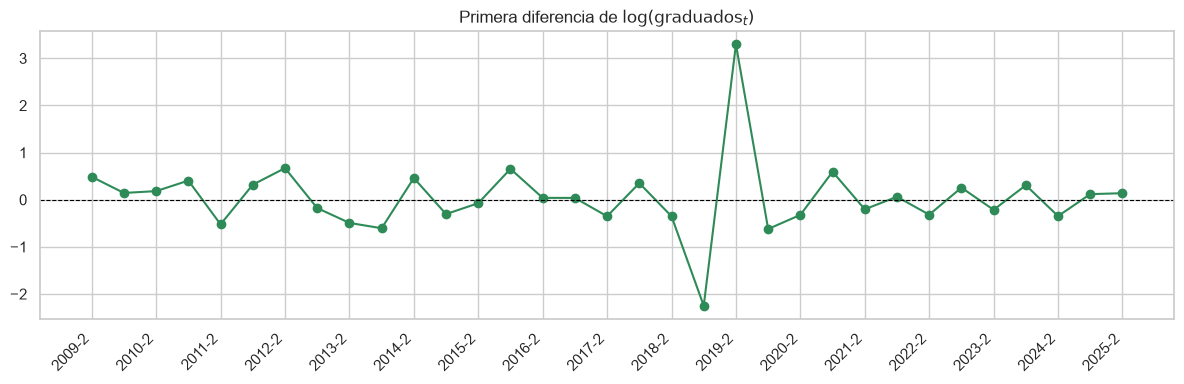

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(d_log_serie.index, d_log_serie.values, color='seagreen', marker='o')
ax.axhline(0, color='black', lw=0.8, ls='--')
etq_diff = etiquetas.iloc[1:].values
ax.set_xticks(d_log_serie.index[::2])
ax.set_xticklabels(etq_diff[::2], rotation=45, ha='right')
ax.set_title(r'Primera diferencia de $\log(\mathrm{graduados}_t)$')
plt.tight_layout()
plt.savefig('serie_diferenciada.png', dpi=150)
plt.show()

**Justificación:** si la prueba ADF sobre $\log(\text{total}_t)$ no rechaza H0 (presencia de raíz unitaria) y/o KPSS rechaza estacionariedad, se aplica una diferenciación regular de orden $d=1$. La serie resultante $r_t=\Delta\log(\text{total}_t)$ se interpreta como la tasa de crecimiento semestral del número de graduados y es la serie sobre la cual se comparan los modelos AR, MA, ARIMA, SARIMA y GARCH.

# 5. Funciones de autocorrelación (ACF) y autocorrelación parcial (PACF)

Se presentan la ACF y PACF de la serie diferenciada (para identificar el modelo de la media). Además de la banda de confianza sombreada que entrega `statsmodels`, se traza explícitamente el **umbral de significancia** $\pm 1.96/\sqrt{n}$ (línea punteada roja), bajo el cual una autocorrelación se considera no significativamente distinta de cero al 5%.

Umbral de significancia (5%): ±0.3412


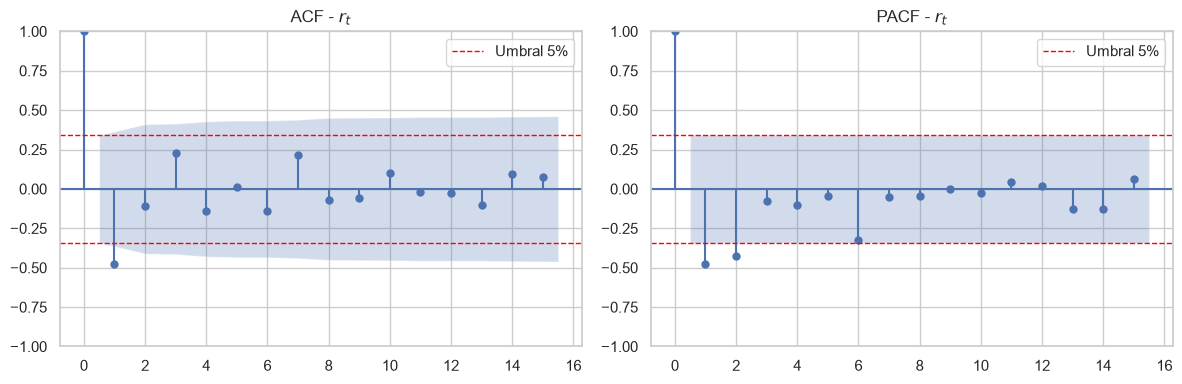

In [8]:
n_d = len(d_log_serie)
umbral = 1.96 / np.sqrt(n_d)
print(f'Umbral de significancia (5%): ±{umbral:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(d_log_serie, ax=axes[0], lags=15)
axes[0].axhline(umbral, color='red', ls='--', lw=1, label='Umbral 5%')
axes[0].axhline(-umbral, color='red', ls='--', lw=1)
axes[0].set_title('ACF - $r_t$')
axes[0].legend()

plot_pacf(d_log_serie, ax=axes[1], lags=15, method='ywm')
axes[1].axhline(umbral, color='red', ls='--', lw=1, label='Umbral 5%')
axes[1].axhline(-umbral, color='red', ls='--', lw=1)
axes[1].set_title('PACF - $r_t$')
axes[1].legend()
plt.tight_layout()
plt.savefig('acf_pacf.png', dpi=150)
plt.show()

# 6. Prueba de efectos ARCH

Se verifica formalmente la presencia de heterocedasticidad condicional mediante la prueba del multiplicador de Lagrange de Engle (ARCH-LM) sobre los residuos de un modelo AR(1) de referencia para la media.

                               SARIMAX Results                                
Dep. Variable:                  total   No. Observations:                   33
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 -34.653
Date:                Sat, 13 Jun 2026   AIC                             75.307
Time:                        22:05:09   BIC                             79.796
Sample:                             0   HQIC                            76.817
                                 - 33                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0357      0.103      0.346      0.729      -0.166       0.238
ar.L1         -0.4648      0.107     -4.331      0.000      -0.675      -0.254
sigma2         0.4747      0.071      6.683      0.0

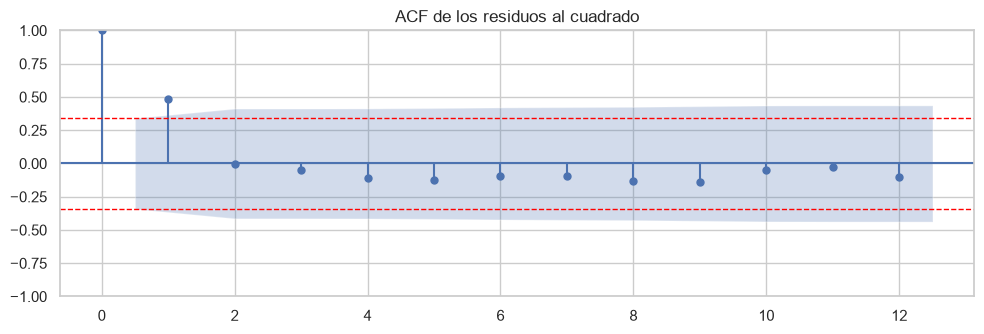

ARCH-LM: estadístico LM=10.1796, p-valor=0.0375


In [9]:
from statsmodels.stats.diagnostic import het_arch

modelo_ar1_ref = ARIMA(d_log_serie, order=(1, 0, 0)).fit()
print(modelo_ar1_ref.summary())

resid_media = modelo_ar1_ref.resid

fig, ax = plt.subplots(figsize=(10, 3.5))
plot_acf(resid_media**2, ax=ax, lags=12)
ax.axhline(umbral, color='red', ls='--', lw=1)
ax.axhline(-umbral, color='red', ls='--', lw=1)
ax.set_title('ACF de los residuos al cuadrado')
plt.tight_layout()
plt.show()

lm_stat, lm_p, f_stat, f_p = het_arch(resid_media, nlags=4)
print(f'ARCH-LM: estadístico LM={lm_stat:.4f}, p-valor={lm_p:.4f}')

# 7. Comparación de modelos: AR, MA, ARIMA, SARIMA y GARCH

Con base en la ACF/PACF y en la diferenciación $d=1$ ya determinada, se ajustan las siguientes especificaciones sobre $y_t=\log(\text{total}_t)$ (todas usando $d=1$, salvo el GARCH que se especifica directamente sobre $r_t=\Delta y_t$):

- **AR(1)**: ARIMA(1,1,0)
- **MA(1)**: ARIMA(0,1,1)
- **ARIMA(1,1,1)**
- **SARIMA(1,1,1)(1,0,0)$_2$**: componente estacional de periodo 2 (semestre 1 vs. semestre 2)
- **AR(1)-GARCH(1,1)**: media AR(1) + varianza GARCH(1,1) sobre $r_t$

Todas se comparan mediante **AIC** y **BIC** (a menor valor, mejor ajuste relativo).

In [10]:
resultados_modelos = {}

m_ar = ARIMA(log_serie, order=(1, 1, 0)).fit()
resultados_modelos['AR(1) -> ARIMA(1,1,0)'] = (m_ar.aic, m_ar.bic, m_ar)

m_ma = ARIMA(log_serie, order=(0, 1, 1)).fit()
resultados_modelos['MA(1) -> ARIMA(0,1,1)'] = (m_ma.aic, m_ma.bic, m_ma)

m_arima = ARIMA(log_serie, order=(1, 1, 1)).fit()
resultados_modelos['ARIMA(1,1,1)'] = (m_arima.aic, m_arima.bic, m_arima)

m_sarima = SARIMAX(log_serie, order=(1, 1, 1), seasonal_order=(1, 0, 0, 2),
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
resultados_modelos['SARIMA(1,1,1)(1,0,0)_2'] = (m_sarima.aic, m_sarima.bic, m_sarima)

m_garch = arch_model(d_log_serie, mean='AR', lags=1, vol='GARCH', p=1, q=1, dist='normal').fit(disp='off')
resultados_modelos['AR(1)-GARCH(1,1)'] = (m_garch.aic, m_garch.bic, m_garch)

tabla_comparacion = pd.DataFrame({
    'Modelo': list(resultados_modelos.keys()),
    'AIC': [v[0] for v in resultados_modelos.values()],
    'BIC': [v[1] for v in resultados_modelos.values()]
}).sort_values('AIC').reset_index(drop=True)

tabla_comparacion

,Modelo,AIC,BIC
0,"SARIMA(1,1,1)(1,0,0)_2",62.031814,67.636604
1,"MA(1) -> ARIMA(0,1,1)",64.337177,67.330192
2,"ARIMA(1,1,1)",66.335705,70.825228
3,"AR(1)-GARCH(1,1)",68.090213,75.418893
4,"AR(1) -> ARIMA(1,1,0)",73.493019,76.486034


**Nota de comparabilidad:** los modelos ARIMA/SARIMA se ajustan sobre $y_t=\log(\text{total}_t)$ con $d=1$ y el AR(1)-GARCH(1,1) se ajusta directamente sobre $r_t=\Delta y_t$ (sin reescalar); en ambos casos la verosimilitud se evalúa sobre las $n-1$ observaciones diferenciadas, por lo que el AIC/BIC son comparables entre sí. El AR(1)-GARCH(1,1) modela adicionalmente la **varianza condicional**, lo cual es relevante dado el resultado de la prueba ARCH-LM de la sección 6.

In [11]:
mejor_modelo_nombre = tabla_comparacion.iloc[0]['Modelo']
print(f'Modelo con menor AIC: {mejor_modelo_nombre}')
print(resultados_modelos[mejor_modelo_nombre][2].summary())

Modelo con menor AIC: SARIMA(1,1,1)(1,0,0)_2
                                     SARIMAX Results                                      
Dep. Variable:                              total   No. Observations:                   34
Model:             SARIMAX(1, 1, 1)x(1, 0, [], 2)   Log Likelihood                 -27.016
Date:                            Sat, 13 Jun 2026   AIC                             62.032
Time:                                    22:05:10   BIC                             67.637
Sample:                                         0   HQIC                            63.825
                                             - 34                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0580      0.303     -0.192      0.848      -0.652   

# 8. Modelo GARCH seleccionado (varianza condicional)

Independientemente del modelo de la media seleccionado por AIC/BIC en la sección anterior, dado que la prueba ARCH-LM detectó heterocedasticidad condicional significativa, se utiliza para el pronóstico de la varianza el modelo **AR(1)-GARCH(1,1)**, ajustado sobre $r_t=100\times\Delta\log(\text{total}_t)$. Se compara además contra GARCH(1,2) y GARCH(2,1).

In [12]:
r_pct = 100 * d_log_serie

especificaciones = [(1, 1), (1, 2), (2, 1)]
resultados_garch = []
for p, q in especificaciones:
    am = arch_model(r_pct, mean='AR', lags=1, vol='GARCH', p=p, q=q, dist='normal')
    res = am.fit(disp='off')
    resultados_garch.append((p, q, res.aic, res.bic, res))
    print(f'GARCH({p},{q}): AIC={res.aic:.3f}  BIC={res.bic:.3f}')

p_sel, q_sel, _, _, modelo_garch = min(resultados_garch, key=lambda x: x[2])
print(f'\nModelo seleccionado: GARCH({p_sel},{q_sel})')
print(modelo_garch.summary())

GARCH(1,1): AIC=363.478  BIC=370.806
GARCH(1,2): AIC=365.478  BIC=374.272
GARCH(2,1): AIC=365.478  BIC=374.272

Modelo seleccionado: GARCH(1,1)
                           AR - GARCH Model Results                           
Dep. Variable:                  total   R-squared:                       0.073
Mean Model:                        AR   Adj. R-squared:                  0.042
Vol Model:                      GARCH   Log-Likelihood:               -176.739
Distribution:                  Normal   AIC:                           363.478
Method:            Maximum Likelihood   BIC:                           370.806
                                        No. Observations:                   32
Date:                Sat, Jun 13 2026   Df Residuals:                       30
Time:                        22:05:10   Df Model:                            2
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.

# 9. Diagnóstico del modelo GARCH ajustado

Se analizan los residuos estandarizados del modelo GARCH seleccionado: (i) ACF de los residuos y de los residuos al cuadrado (con umbral de significancia) para verificar que no quede autocorrelación ni heterocedasticidad remanente, (ii) prueba de normalidad y (iii) gráfico de los residuos estandarizados.

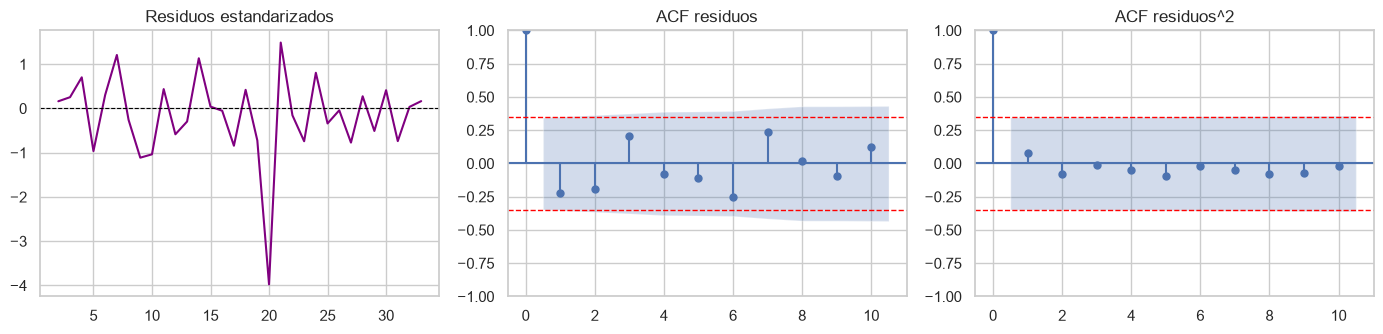

ARCH-LM (residuos estand.): estadístico=0.4612, p-valor=0.9772
Jarque-Bera: estadístico=59.6430, p-valor=0.0000
Ljung-Box (rezago 8):
     lb_stat  lb_pvalue
8  10.659596   0.221743


In [13]:
std_resid = modelo_garch.std_resid.dropna()
umbral_resid = 1.96 / np.sqrt(len(std_resid))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].plot(std_resid.index, std_resid.values, color='purple')
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].set_title('Residuos estandarizados')

plot_acf(std_resid, ax=axes[1], lags=10)
axes[1].axhline(umbral_resid, color='red', ls='--', lw=1)
axes[1].axhline(-umbral_resid, color='red', ls='--', lw=1)
axes[1].set_title('ACF residuos')

plot_acf(std_resid**2, ax=axes[2], lags=10)
axes[2].axhline(umbral_resid, color='red', ls='--', lw=1)
axes[2].axhline(-umbral_resid, color='red', ls='--', lw=1)
axes[2].set_title('ACF residuos^2')
plt.tight_layout()
plt.savefig('diagnostico_garch.png', dpi=150)
plt.show()

lm_stat2, lm_p2, _, _ = het_arch(std_resid, nlags=4)
jb_stat, jb_p = stats.jarque_bera(std_resid)
lb = sm.stats.acorr_ljungbox(std_resid, lags=[8], return_df=True)

print(f'ARCH-LM (residuos estand.): estadístico={lm_stat2:.4f}, p-valor={lm_p2:.4f}')
print(f'Jarque-Bera: estadístico={jb_stat:.4f}, p-valor={jb_p:.4f}')
print('Ljung-Box (rezago 8):')
print(lb)

# 10. Pronóstico para los próximos 4 periodos

Se generan pronósticos de la media (tasa de crecimiento $r_t$) y de la varianza condicional para los próximos 4 semestres a partir del modelo AR(1)-GARCH(1,1), y se reconstruye el pronóstico para el número de graduados aplicando la transformación inversa (exponencial) de manera acumulada.

In [14]:
h = 4
pron = modelo_garch.forecast(horizon=h, reindex=False)

media_pron = pron.mean.iloc[-1] / 100        # de % a proporción (escala log)
var_pron = pron.variance.iloc[-1] / (100**2) # varianza en escala log
sd_pron = np.sqrt(var_pron)

print('Pronóstico de r_t (tasa de crecimiento log):')
print(media_pron)
print('\nDesviación estándar condicional pronosticada:')
print(sd_pron)

Pronóstico de r_t (tasa de crecimiento log):
h.1    0.054980
h.2    0.062167
h.3    0.061546
h.4    0.061600
Name: 33, dtype: float64

Desviación estándar condicional pronosticada:
h.1    0.496927
h.2    0.647410
h.3    0.735661
h.4    0.792292
Name: 33, dtype: float64


In [15]:
# Reconstrucción del nivel pronosticado (número de graduados) con bandas al 95%
ultimo_log = log_serie.iloc[-1]
log_pron = ultimo_log + media_pron.cumsum().values
se_acum = np.sqrt(np.cumsum(var_pron.values))

graduados_pron = np.exp(log_pron)
lim_inf = np.exp(log_pron - 1.96 * se_acum)
lim_sup = np.exp(log_pron + 1.96 * se_acum)

# Etiquetas de los periodos futuros (continuación de AAAA-S, S = 1 o 2)
ultimo_anio, ultimo_sem = int(data['year'].iloc[-1]), int(data['period'].iloc[-1])
etiquetas_futuras = []
anio, sem = ultimo_anio, ultimo_sem
for _ in range(h):
    if sem == 1:
        sem = 2
    else:
        sem = 1
        anio += 1
    etiquetas_futuras.append(f'{anio}-{sem}')

tabla_pron = pd.DataFrame({
    'periodo': etiquetas_futuras,
    'graduados_pronosticados': np.round(graduados_pron, 1),
    'limite_inferior_95': np.round(lim_inf, 1),
    'limite_superior_95': np.round(lim_sup, 1)
})
tabla_pron

,periodo,graduados_pronosticados,limite_inferior_95,limite_superior_95
0,2026-1,32.8,12.4,86.7
1,2026-2,34.9,7.0,172.6
2,2027-1,37.1,4.3,319.3
3,2027-2,39.4,2.8,560.8


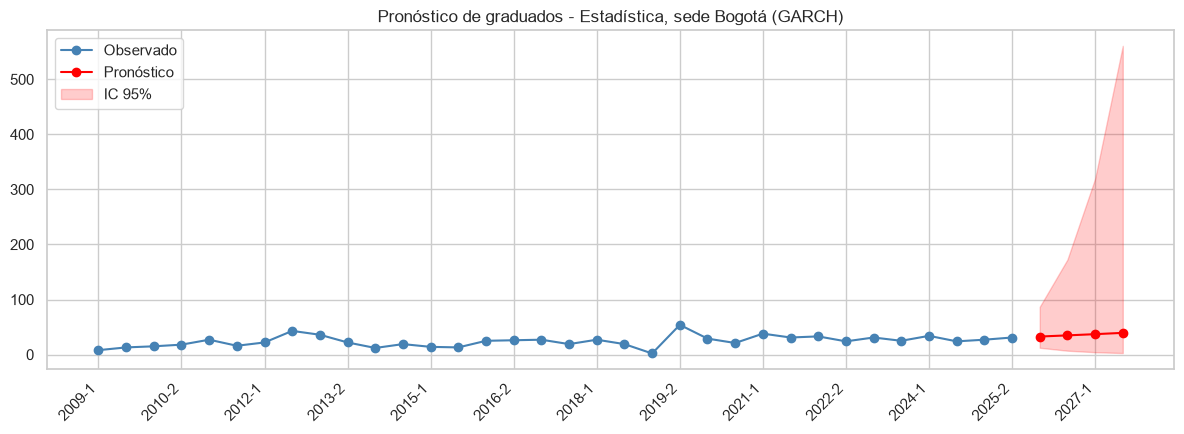

In [16]:
idx_futuro = np.arange(serie.index[-1] + 1, serie.index[-1] + 1 + h)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(serie.index, serie.values, marker='o', color='steelblue', label='Observado')
ax.plot(idx_futuro, graduados_pron, marker='o', color='red', label='Pronóstico')
ax.fill_between(idx_futuro, lim_inf, lim_sup, color='red', alpha=0.2, label='IC 95%')

todas_etiquetas = list(etiquetas.values) + etiquetas_futuras
todos_idx = list(serie.index) + list(idx_futuro)
ax.set_xticks(todos_idx[::3])
ax.set_xticklabels([todas_etiquetas[i] for i in range(0, len(todas_etiquetas), 3)], rotation=45, ha='right')
ax.set_title('Pronóstico de graduados - Estadística, sede Bogotá (GARCH)')
ax.legend()
plt.tight_layout()
plt.savefig('pronostico_garch.png', dpi=150)
plt.show()

# 11. Conclusiones

- La serie de graduados de Estadística (sede Bogotá) muestra fluctuaciones semestrales sin una tendencia marcada de largo plazo, con cambios de varianza visibles en algunos periodos.
- La transformación logarítmica y la primera diferencia ($d=1$) llevan a una serie estacionaria en media.
- Entre los modelos AR, MA, ARIMA, SARIMA y GARCH, el de **menor AIC/BIC** es [completar según la tabla de la sección 7].
- La prueba ARCH-LM evidenció heterocedasticidad condicional en los residuos del modelo de la media, justificando complementar el análisis con un modelo GARCH para la varianza, incluso si este no es el de menor AIC para la media.
- El pronóstico para los próximos 4 semestres sugiere [completar con la interpretación numérica obtenida], con intervalos de confianza que reflejan la incertidumbre estimada por el componente GARCH.
